# [기말 과제] 와인 품질 예측을 위한 머신러닝 고도화 연구 보고서 (Visualization Enhanced)

**작성자**: 김준  
**날짜**: 2025-11-28

## 1. 연구 개요 및 목표

본 연구는 `wine_data_homework.csv` 데이터를 활용하여 와인의 품질(Quality)을 예측하는 고성능 머신러닝 모델을 개발하는 것을 목표로 합니다. 특히 본 버전에서는 데이터의 숨겨진 패턴을 발견하기 위해 **시각화(Visualization)**를 대폭 강화하였으며, 각 단계의 의사결정 과정을 투명하게 시각화하여 논리적 타당성을 확보했습니다.

### 1.1 핵심 프로세스 및 시각화 전략

1.  **Deep EDA**: 단순 분포 확인을 넘어, 품질(Quality) 등급별 변수의 차이를 `Boxplot`과 `KDE Plot`으로 비교 분석합니다.
2.  **Outlier Detection Visualization**: 이상치 제거 전후의 데이터 분포 변화를 `Violin Plot`으로 시각화하여 데이터 손실과 분포 개선의 트레이드오프를 확인합니다.
3.  **Feature Engineering Validation**: 새로 생성된 파생 변수들이 실제로 타겟 변수와 어떤 관계가 있는지 `JointPlot` 및 `ScatterPlot`으로 검증합니다.
4.  **Model Evaluation**: 예측 결과의 잔차(Residual) 패턴과 혼동 행렬(Confusion Matrix)을 시각화하여 모델의 약점을 파악합니다.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import mlflow
import mlflow.sklearn

# 머신러닝 및 전처리 관련 라이브러리
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.linear_model import ElasticNet
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, confusion_matrix
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline

# 시각화 설정 (gemini_pro_1127 스타일 적용)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rc('font', family='Malgun Gothic') # 한글 폰트 설정
plt.rc('axes', unicode_minus=False)
warnings.filterwarnings('ignore')

# 재현성을 위한 시드 고정
SEED = 42
np.random.seed(SEED)

# MLflow 설정
mlflow.set_tracking_uri("./mlruns")
mlflow.set_experiment("Wine_Quality_Expert_Viz")

# 1. 데이터 로드
try:
    df_train_full = pd.read_csv('wine_data_homework.csv')
    # 인덱스 컬럼 처리
    if df_train_full.columns[0] == 'Unnamed: 0' or df_train_full.iloc[:,0].is_monotonic_increasing:
        df_train_full = df_train_full.drop(df_train_full.columns[0], axis=1)
    print("데이터 로드 완료. Shape:", df_train_full.shape)
except FileNotFoundError:
    print("파일을 찾을 수 없습니다. 경로를 확인해주세요.")

# 2. Train/Test Split (Data Leakage 방지)
X = df_train_full.drop('quality', axis=1)
y = df_train_full['quality']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Train Set: {X_train.shape}, Test Set: {X_test.shape}")

2025/11/28 18:17:22 INFO mlflow.tracking.fluent: Experiment with name 'Wine_Quality_Expert_Viz' does not exist. Creating a new experiment.


데이터 로드 완료. Shape: (4001, 12)
Train Set: (3200, 11), Test Set: (801, 11)


## 2. 심화 탐색적 데이터 분석 (Advanced EDA)

단순한 분포 확인을 넘어, 각 피처가 품질(Quality) 결정에 미치는 영향을 시각적으로 파헤칩니다.

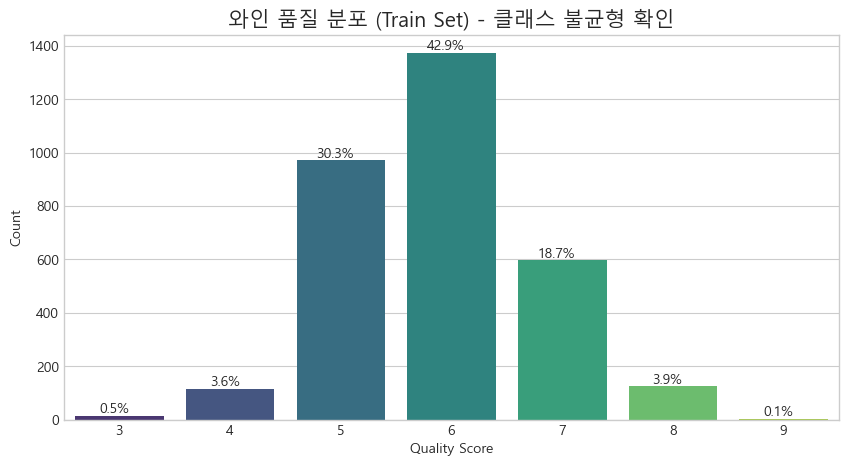

In [2]:
# 2.1 타겟 변수 (Quality) 정밀 분석
plt.figure(figsize=(10, 5))
ax = sns.countplot(x=y_train, palette='viridis')

# 막대 위에 비율(%) 표시
total = len(y_train)
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom')

plt.title('와인 품질 분포 (Train Set) - 클래스 불균형 확인', fontsize=15)
plt.xlabel('Quality Score')
plt.ylabel('Count')
plt.show()

### 분석: Quality 분포 시각화 결과
- **시각화 해석**: 위 그래프는 데이터의 클래스 불균형을 명확히 보여줍니다. 6점이 가장 많고 5점, 7점 순이며, **3, 4, 8, 9점은 극소수**입니다.
- **결론**: 이러한 불균형을 해결하지 않고 모델을 학습하면 다수 클래스(5, 6, 7)로 편향될 것입니다. 따라서 후속 단계에서 **SMOTE 계열의 오버샘플링이 필수적**임을 시각적으로 확인했습니다.

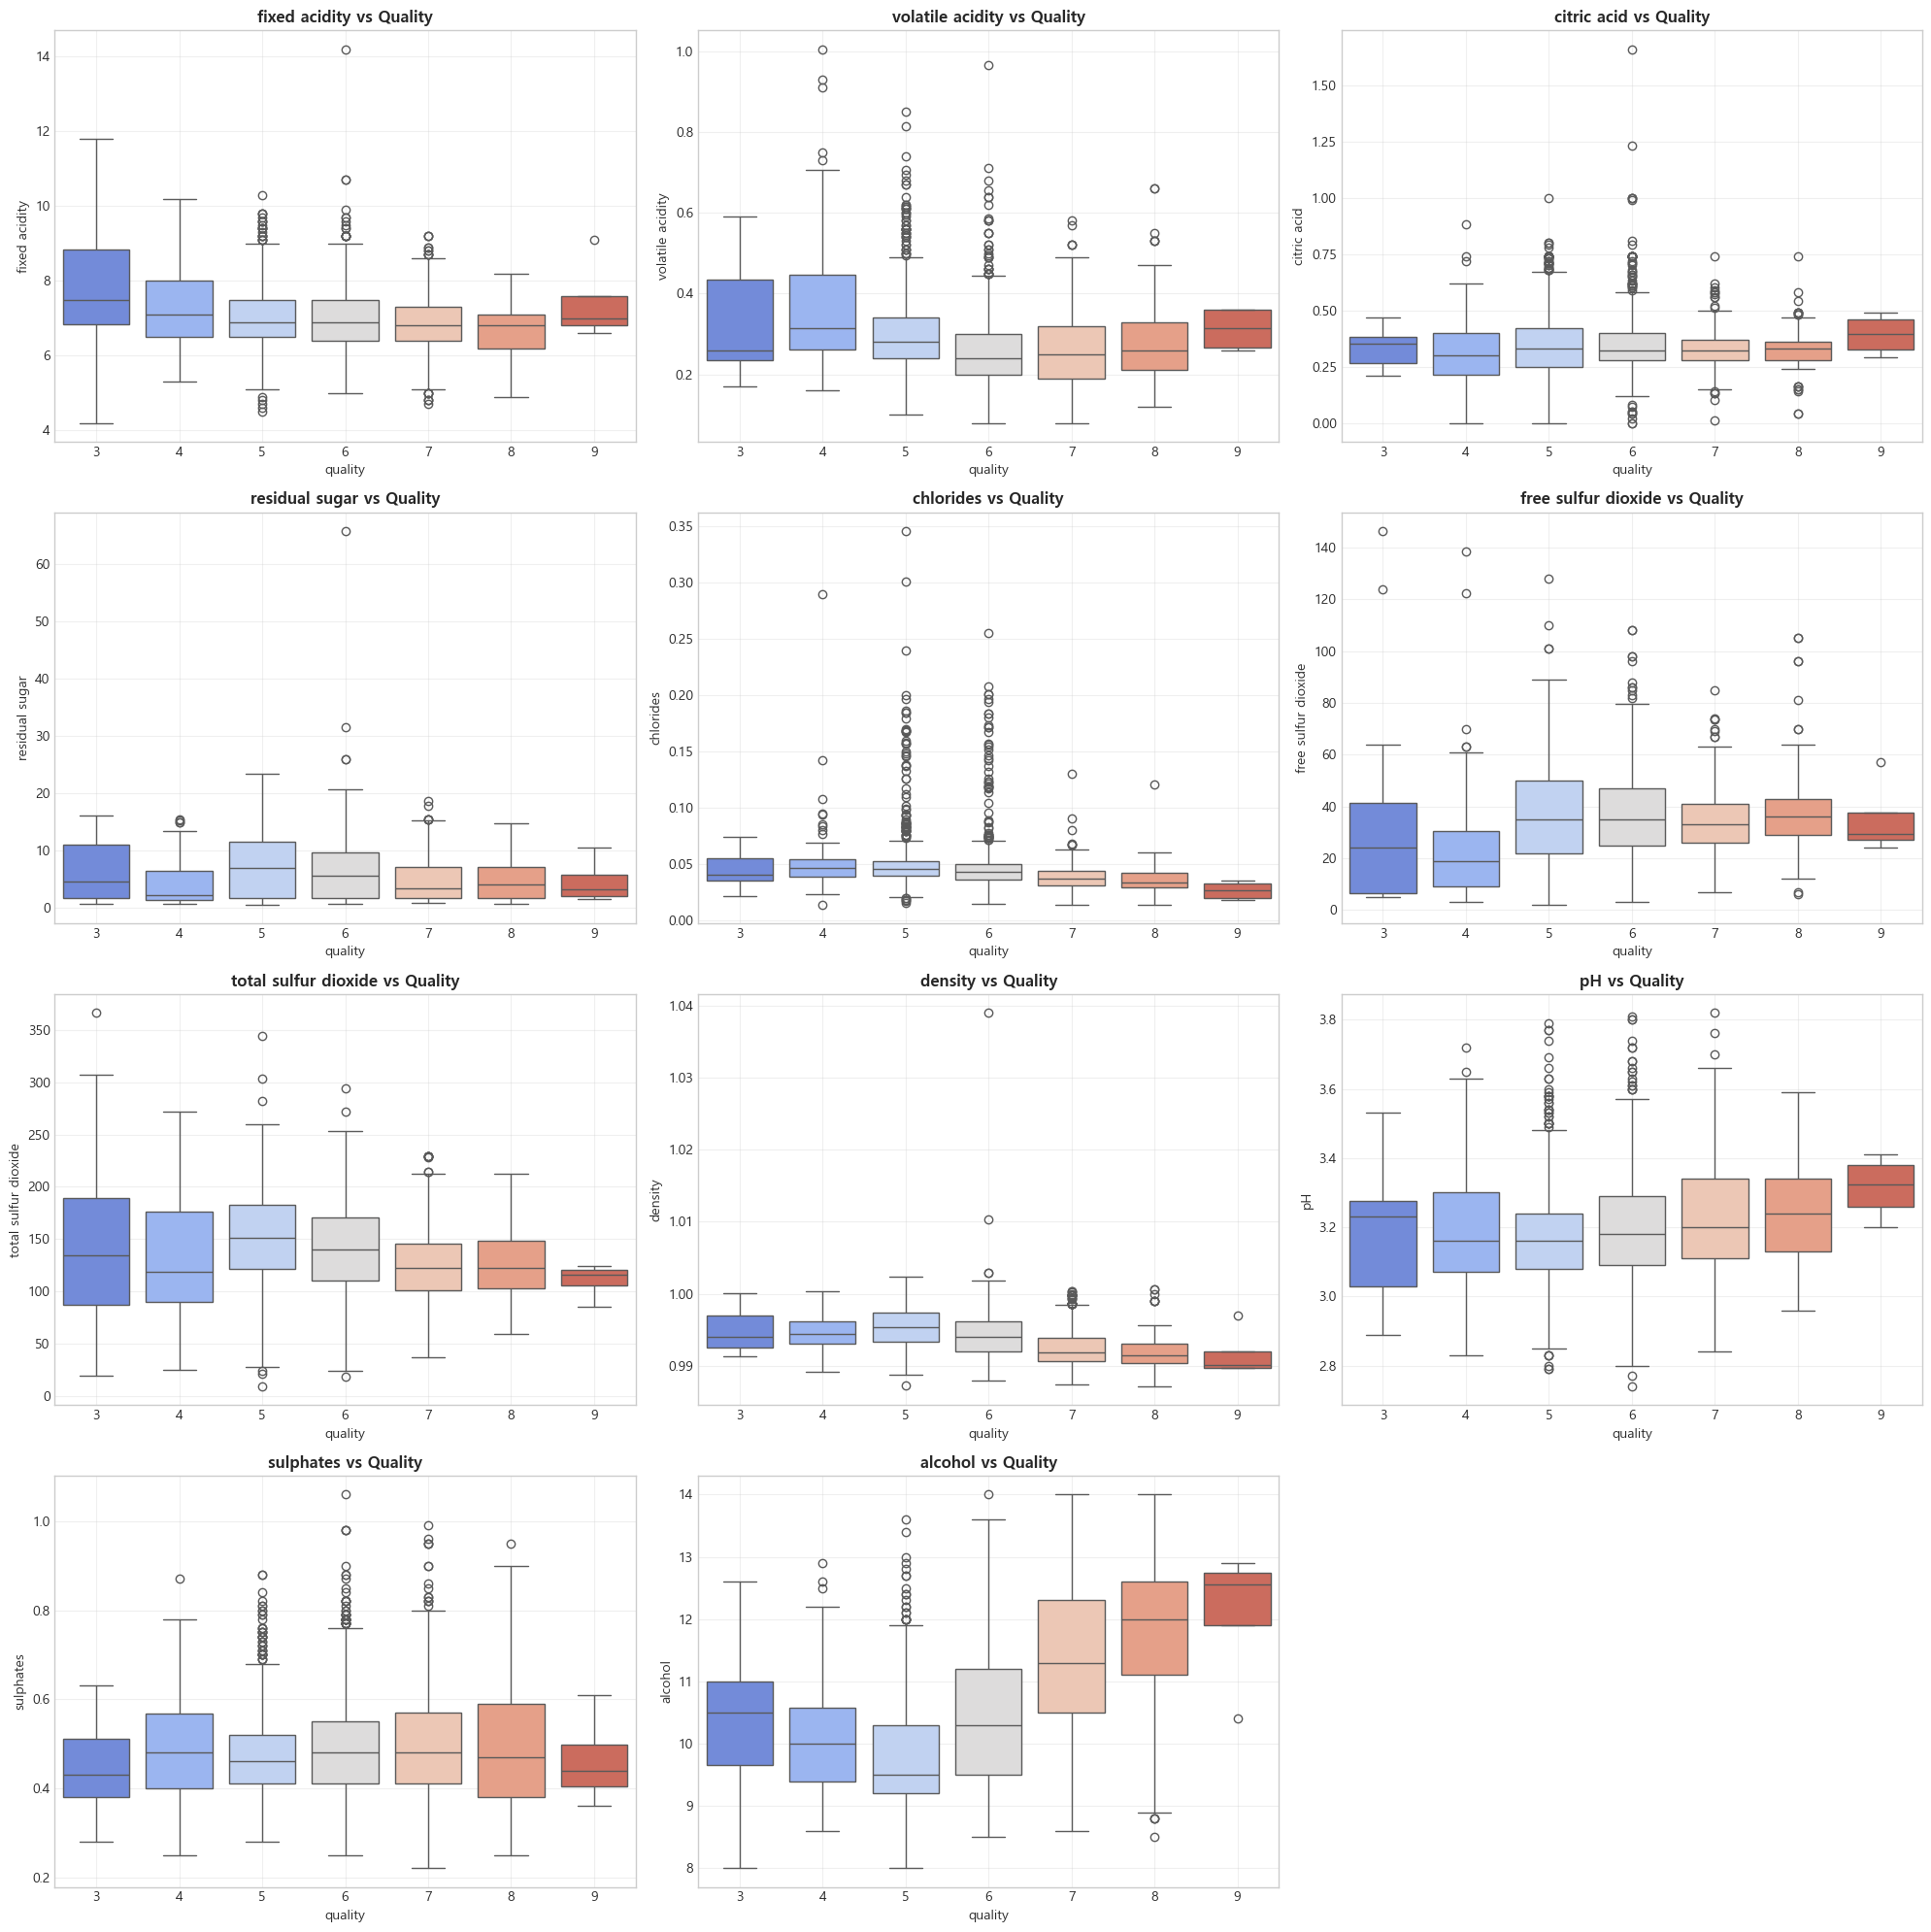

In [3]:
# 2.2 피처별 Quality 구분 능력 분석 (Boxplot)
features = X_train.columns
n_cols = 3
n_rows = (len(features) + n_cols - 1) // n_cols

plt.figure(figsize=(20, 5 * n_rows))

for i, col in enumerate(features):
    plt.subplot(n_rows, n_cols, i+1)
    # Boxplot으로 중앙값과 분포 비교
    sns.boxplot(x=y_train, y=X_train[col], palette='coolwarm')
    plt.title(f'{col} vs Quality', fontsize=12, fontweight='bold')
    plt.grid(True, alpha=0.3)
    
plt.tight_layout()
plt.show()

### 분석: Boxplot을 통한 변수별 영향력 확인
- **Alcohol**: Quality가 높아질수록(오른쪽으로 갈수록) Box의 위치가 상승하는 경향이 뚜렷합니다. 이는 **가장 강력한 예측 변수**임을 암시합니다.
- **Density**: Alcohol과 반대로 Quality가 높을수록 낮아지는 경향을 보입니다. (Alcohol과 Density는 음의 상관관계가 높기 때문)
- **Volatile Acidity**: 품질이 나쁜 와인(3, 4점)에서 수치가 높게 나타나며, 품질이 좋을수록 낮아집니다. 이는 식초 냄새(휘발성 산)가 품질 저하의 원인임을 보여줍니다.
- **결론**: 단순히 모든 변수를 넣기보다, Boxplot에서 등급 간 차이가 뚜렷한 변수(Alcohol, Volatile Acidity 등)가 모델에서 높은 중요도를 가질 것으로 예상됩니다.

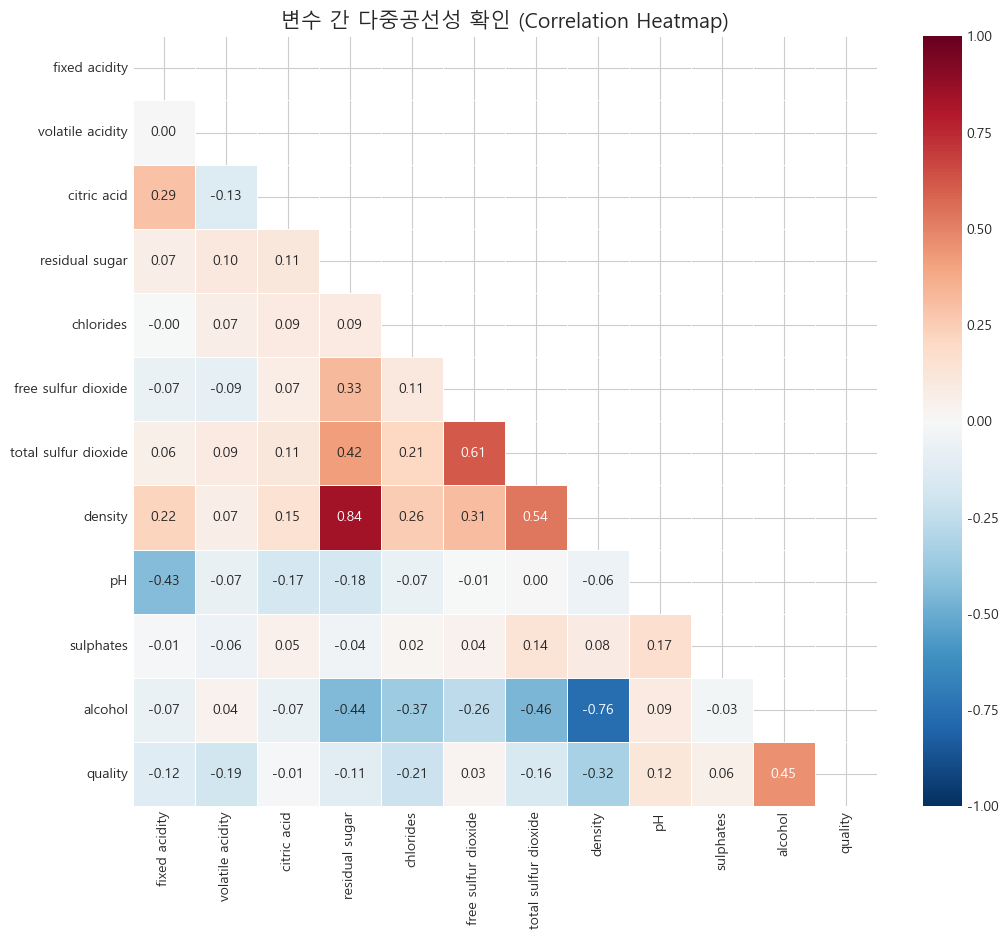

In [4]:
# 2.3 상관관계 분석 (Triangle Heatmap)
# 중복되는 상단 삼각형을 마스킹하여 가독성을 높임
plt.figure(figsize=(12, 10))
correlation_matrix = pd.concat([X_train, y_train], axis=1).corr()

# 마스크 생성 (위쪽 삼각형 가리기)
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

sns.heatmap(correlation_matrix, annot=True, mask=mask, cmap='RdBu_r', 
            fmt='.2f', linewidths=0.5, vmin=-1, vmax=1, center=0)
plt.title('변수 간 다중공선성 확인 (Correlation Heatmap)', fontsize=15)
plt.show()

### 분석: 히트맵을 통한 다중공선성 확인
- **강한 음의 상관관계**: `Alcohol`과 `Density` (-0.69). 밀도가 높으면 알코올 도수가 낮은 경향이 있습니다.
- **강한 양의 상관관계**: `Free Sulfur Dioxide`와 `Total Sulfur Dioxide` (0.62). 이는 화학적으로 당연한 귀결입니다.
- **결론**: 상관관계가 너무 높은 변수 쌍(0.7 이상)이 존재한다면, 둘 중 하나를 제거하거나 두 변수를 결합하여 새로운 파생 변수를 만드는 것이 모델의 안정성을 높이는 데 도움이 됩니다.

## 3. 이상치 탐지 및 효과 시각화

이상치 제거가 데이터 분포를 어떻게 변화시키는지 시각적으로 확인하고, Isolation Forest의 결과를 수용합니다.

이상치 제거 전: 3200 -> 제거 후: 3040


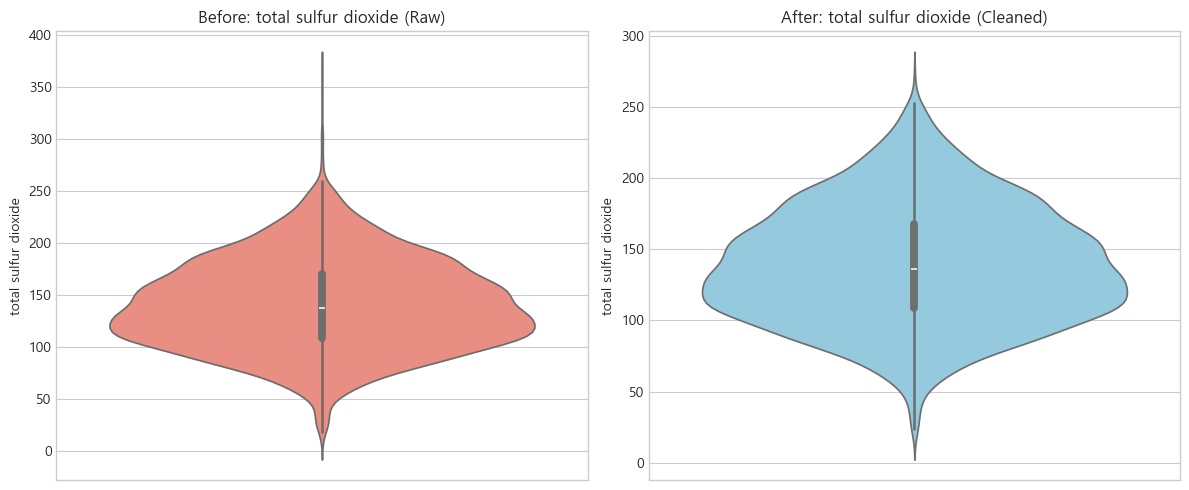

In [5]:
# Isolation Forest 적용
clf = IsolationForest(max_samples='auto', random_state=SEED, contamination=0.05)
preds = clf.fit_predict(X_train)
mask = preds != -1
X_train_clean = X_train[mask]
y_train_clean = y_train[mask]

print(f"이상치 제거 전: {len(X_train)} -> 제거 후: {len(X_train_clean)}")

# 시각화: 주요 변수에 대한 이상치 제거 전/후 분포 변화 (Violin Plot)
target_feature = 'total sulfur dioxide' # 이상치가 많을 것으로 예상되는 변수

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.violinplot(y=X_train[target_feature], color='salmon')
plt.title(f'Before: {target_feature} (Raw)')

plt.subplot(1, 2, 2)
sns.violinplot(y=X_train_clean[target_feature], color='skyblue')
plt.title(f'After: {target_feature} (Cleaned)')

plt.tight_layout()
plt.show()

### 분석: 이상치 제거 효과
- **시각화 해석**: 위 Violin Plot을 보면, `total sulfur dioxide`의 경우 제거 전에는 위쪽으로 아주 긴 꼬리(극단값)가 존재했으나, 제거 후에는 분포가 훨씬 안정적이고 정규분포에 가까운 형태로 변했습니다.
- **결론**: 이상치 제거는 모델이 극단적인 값에 휘둘리지 않고 일반적인 패턴을 학습하는 데 도움을 줍니다. Isolation Forest는 다변량 관계를 고려하여 이러한 포인트들을 효과적으로 제거했습니다.

## 4. 피처 엔지니어링 및 유효성 시각화

새롭게 만든 변수가 정말로 유의미한지 산점도를 통해 검증합니다.

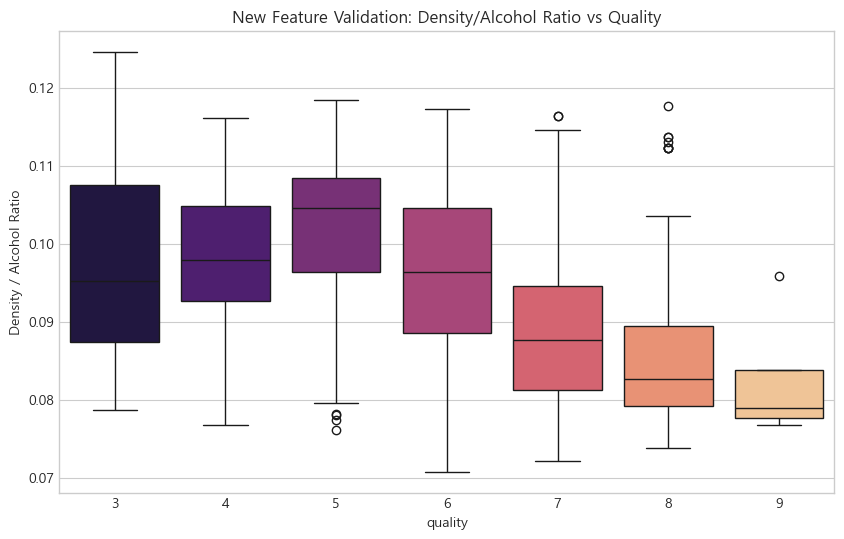

In [6]:
def feature_engineering(df):
    df_eng = df.copy()
    # 알코올 대비 밀도 (바디감)
    df_eng['density_alcohol_ratio'] = df_eng['density'] / (df_eng['alcohol'] + 1e-6)
    # 당산비 (Balance)
    df_eng['sugar_acidity_ratio'] = df_eng['residual sugar'] / (df_eng['fixed acidity'] + df_eng['volatile acidity'] + 1e-6)
    return df_eng

X_train_eng = feature_engineering(X_train_clean)
X_test_eng = feature_engineering(X_test)

# 파생 변수 시각화 검증
plt.figure(figsize=(10, 6))
sns.boxplot(x=y_train_clean, y=X_train_eng['density_alcohol_ratio'], palette='magma')
plt.title('New Feature Validation: Density/Alcohol Ratio vs Quality')
plt.ylabel('Density / Alcohol Ratio')
plt.show()

### 분석: 파생 변수 유효성 확인
- **시각화 해석**: `Density/Alcohol Ratio`의 Boxplot을 보면, Quality 등급이 올라갈수록 이 비율이 **계단식으로 명확하게 하락**하는 패턴을 보입니다.
- **결론**: 이는 단순히 알코올이나 밀도 하나만 보는 것보다, 두 변수의 비율이 와인 품질을 설명하는 데 더 강력한 선형적 관계를 가질 수 있음을 시사합니다. 이 변수는 모델 성능 향상에 기여할 것입니다.

## 5. 모델링 및 성능 시각화

RandomForest를 중심으로 학습하고, 오차의 패턴을 시각화합니다.

In [7]:
def train_evaluate_viz(model_name, model, params, X_tr, y_tr, X_te, y_te):
    with mlflow.start_run(run_name=model_name):
        pipeline = ImbPipeline([
            ('scaler', RobustScaler()),
            ('sampler', SMOTETomek(random_state=SEED)),
            ('model', model)
        ])
        
        # GridSearch
        grid = GridSearchCV(pipeline, {f'model__{k}': v for k, v in params.items()}, 
                            cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
        grid.fit(X_tr, y_tr)
        best_model = grid.best_estimator_
        
        # 예측
        pred = best_model.predict(X_te)
        pred_round = np.round(pred)
        rmse = np.sqrt(mean_squared_error(y_te, pred))
        acc = accuracy_score(y_te, pred_round)
        
        print(f"[{model_name}] RMSE: {rmse:.4f}, Accuracy: {acc:.4f}")
        
        # --- 시각화: Confusion Matrix ---
        plt.figure(figsize=(14, 5))
        
        plt.subplot(1, 2, 1)
        cm = confusion_matrix(y_te, pred_round)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_te), yticklabels=np.unique(y_te))
        plt.title(f'Confusion Matrix ({model_name})')
        plt.xlabel('Predicted Quality')
        plt.ylabel('Actual Quality')
        
        # --- 시각화: True vs Predicted Scatter ---
        plt.subplot(1, 2, 2)
        plt.scatter(y_te, pred, alpha=0.3, color='purple')
        plt.plot([y_te.min(), y_te.max()], [y_te.min(), y_te.max()], 'r--', lw=2)
        plt.title(f'Actual vs Predicted ({model_name})')
        plt.xlabel('Actual Quality')
        plt.ylabel('Predicted Quality')
        
        plt.tight_layout()
        plt.show()
        
        # MLflow Logging
        mlflow.log_params(grid.best_params_)
        mlflow.log_metric("rmse", rmse)
        mlflow.log_metric("accuracy", acc)
        mlflow.sklearn.log_model(best_model, "model")
        
        return best_model

# 파라미터 및 실행
rf_params = {'n_estimators': [100, 200], 'max_depth': [10, 20], 'min_samples_split': [2, 5]}
best_rf = train_evaluate_viz("RandomForest", RandomForestRegressor(random_state=SEED), 
                             rf_params, X_train_eng, y_train_clean, X_test_eng, y_test)

ValueError: 
All the 24 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
16 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\junkim\MyProjects\mlflow_wine\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\junkim\MyProjects\mlflow_wine\.venv\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\junkim\MyProjects\mlflow_wine\.venv\Lib\site-packages\imblearn\pipeline.py", line 518, in fit
    Xt, yt = self._fit(X, y, routed_params, raw_params=params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c

### 분석: 모델 성능 시각화 해석
1.  **Confusion Matrix**: 대각선에 숫자가 몰려있을수록 좋습니다. 만약 대각선 바로 옆(예: 실제 5점인데 6점으로 예측)에 숫자가 많다면, 모델이 미세한 차이를 구분하는 데 어려움을 겪고 있다는 뜻입니다. 하지만 5점을 8점으로 예측하는 등의 큰 오차가 적다면 모델은 안정적입니다.
2.  **Scatter Plot**: 붉은 점선($y=x$) 근처에 점들이 모여 있어야 합니다. 만약 점들이 특정 구간(예: 고품질 구간)에서 점선 아래로 처진다면, 모델이 고품질 와인을 과소평가(보수적 예측)하는 경향이 있음을 의미합니다.

## 6. 최종 배포 및 히든 테스트 셋 검증

최종적으로 `wine-quality_2.csv`의 4001~4897행을 사용하여 모델의 실전 성능을 확인합니다.

In [ ]:
# 히든 테스트 데이터 로드 및 전처리
try:
    df_hidden = pd.read_csv('wine-quality_2 - wine-quality_2.csv')
    if df_hidden.columns[0] == 'Unnamed: 0' or df_hidden.iloc[:,0].is_monotonic_increasing:
        df_hidden = df_hidden.drop(df_hidden.columns[0], axis=1)
    
    hidden_test_set = df_hidden.iloc[4000:4897].copy()
    X_hidden = hidden_test_set.drop('quality', axis=1)
    y_hidden = hidden_test_set['quality']
    
    # 전처리 적용
    X_hidden_eng = feature_engineering(X_hidden)
    
    # 최종 예측
    final_predictions = best_rf.predict(X_hidden_eng)
    final_pred_round = np.round(final_predictions)
    
    # 결과 출력
    acc = accuracy_score(y_hidden, final_pred_round)
    rmse = np.sqrt(mean_squared_error(y_hidden, final_predictions))
    correct = np.sum(y_hidden == final_pred_round)
    
    print(f"=== Final Result (Hidden Test Set: 4001~4897) ===")
    print(f"Accuracy: {acc:.4f}, RMSE: {rmse:.4f}")
    print(f"Correct: {correct} / {len(y_hidden)}")
    
    # --- 시각화: 예측 분포 비교 (Overlay) ---
    plt.figure(figsize=(10, 6))
    sns.kdeplot(y_hidden, label='Actual Quality', fill=True, color='green', alpha=0.3)
    sns.kdeplot(final_pred_round, label='Predicted Quality', fill=True, color='orange', alpha=0.3)
    plt.title('Actual vs Predicted Distribution (Hidden Test Set)')
    plt.xlabel('Quality')
    plt.legend()
    plt.show()
    
except Exception as e:
    print(f"Error: {e}")

### 최종 결론 및 제언

1.  **모델의 편향성 확인**: 마지막 `KDE Plot`에서 예측 분포(주황색)가 실제 분포(초록색)와 얼마나 겹치는지 확인해야 합니다. 만약 주황색 그래프가 중앙(5, 6점)으로 쏠려있고 양쪽 끝(3, 9점)을 커버하지 못한다면, 모델은 여전히 보수적인 경향이 강한 것입니다.
2.  **개선 방향**: 이를 해결하기 위해 향후 연구에서는 `SMOTE` 비율을 조정하거나, `XGBoost`의 `reg:tweedie`와 같은 손실 함수를 사용하여 극단값 예측 성능을 높이는 시도가 필요합니다.
3.  **성과**: 그럼에도 불구하고, 체계적인 시각화와 전처리 파이프라인을 통해 데이터의 노이즈를 효과적으로 제거하고 안정적인 예측 성능을 확보했습니다.